# Coin classifier model comparison

Compare **CNN**, **ResNet18**, **SVM**, and **RTrees** on the same test set with many graphs and DL-specific analysis.

**Models**: `data/models/coin_cnn.pt`, `coin_resnet18.pt`, `coin_svm.yaml`, `coin_rtrees.yaml`

**If you get `'RcParams' object has no attribute '_get'`:** your kernel may be using the system matplotlib instead of the venv. Run the cell below once (with your venv active), then restart the kernel and run again. Alternatively, the next cell forces the `Agg` backend so the notebook can run with an older system matplotlib.

In [ ]:
# Optional: run once to install/upgrade matplotlib in the current (venv) Python, then restart kernel
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "matplotlib"])
print("Restart the kernel and run the notebook again.")

## 1. Setup and paths

In [21]:
import os
import json
import time
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, auc, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize
import pandas as pd

REPO_ROOT = Path(os.getcwd())
if not (REPO_ROOT / "data" / "models").exists():
    REPO_ROOT = Path(__file__).resolve().parent if "__file__" in dir() else Path(".")
DATA_DIR = REPO_ROOT / "data"
MODELS_DIR = DATA_DIR / "models"
DATA_ROOT = DATA_DIR / "training_data_2"

NUM_CLASSES = 6
CROP_SIZE = 150
CLASS_NAMES = ["20 cent", "10 cent", "1 euro", "1 cent", "2 cent", "5 cent"]
CLASS_DIRS = ["20cent", "10cent", "1euro", "1cent", "2cent", "5cent"]
LABEL_TO_ID = {d: i for i, d in enumerate(CLASS_DIRS)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Models: {MODELS_DIR}")
print(f"Training data: {DATA_ROOT}")

Device: cuda
Models: /home/david/master upm/car-uav/coin_counter_simple/coin_counter_cpp/data/models
Training data: /home/david/master upm/car-uav/coin_counter_simple/coin_counter_cpp/data/training_data_2


## 2. Data loading (same validation split as training)

Load samples from `training_data_2` (images/ + labels/*.json). Build 150×150 crops for DL and 4-D features for SVM/RTrees.

**Important**: Uses `torch.utils.data.random_split` with `Generator().manual_seed(42)` — the exact same split as `coin_cnn_training.ipynb` — so the test set here equals the validation set used during training (no data leakage).

In [ ]:
from torch.utils.data import random_split

def load_ratio_px_to_mm():
    cal_path = MODELS_DIR / "coin_calibration_robust.yaml"
    if cal_path.is_file():
        fs = cv2.FileStorage(str(cal_path), cv2.FILE_STORAGE_READ)
        if fs.isOpened():
            node = fs.getNode("ratio_px_to_mm")
            if not node.empty():
                val = node.real()
                fs.release()
                return float(val)
            fs.release()
    return 1.0 / 5.46104

def extract_crop(bgr, cx, cy, crop_size, h, w):
    half = crop_size // 2
    x1, y1 = cx - half, cy - half
    x2, y2 = cx + half, cy + half
    out = np.zeros((crop_size, crop_size, 3), dtype=bgr.dtype)
    src_x1, src_y1 = max(0, x1), max(0, y1)
    src_x2, src_y2 = min(w, x2), min(h, y2)
    dst_x1, dst_y1 = src_x1 - x1, src_y1 - y1
    dst_x2 = dst_x1 + (src_x2 - src_x1)
    dst_y2 = dst_y1 + (src_y2 - src_y1)
    if dst_x2 > dst_x1 and dst_y2 > dst_y1:
        out[dst_y1:dst_y2, dst_x1:dst_x2] = bgr[src_y1:src_y2, src_x1:src_x2]
    return out

def sample_mean_lab_inside_circle(bgr, center_xy, radius_px):
    h, w = bgr.shape[:2]
    cx, cy = center_xy
    inner_r = max(2, int(radius_px * 0.7))
    y0, y1 = max(0, cy - inner_r), min(h, cy + inner_r + 1)
    x0, x1 = max(0, cx - inner_r), min(w, cx + inner_r + 1)
    if y1 <= y0 or x1 <= x0:
        return None
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    roi = lab[y0:y1, x0:x1]
    mask = np.zeros((roi.shape[0], roi.shape[1]), dtype=np.uint8)
    for y in range(roi.shape[0]):
        for x in range(roi.shape[1]):
            gx, gy = x0 + x - cx, y0 + y - cy
            if gx*gx + gy*gy <= inner_r*inner_r:
                mask[y, x] = 255
    mean_val = cv2.mean(roi, mask=mask)
    return np.array([mean_val[0], mean_val[1], mean_val[2]], dtype=np.float64)

def extract_features(bgr, diameter_mm):
    if bgr is None or bgr.size == 0:
        return None
    h, w = bgr.shape[:2]
    cx, cy = w // 2, h // 2
    radius_px = max(2, int(min(w, h) * 0.35))
    lab_vec = sample_mean_lab_inside_circle(bgr, (cx, cy), radius_px)
    if lab_vec is None:
        return None
    return np.array([diameter_mm, lab_vec[0], lab_vec[1], lab_vec[2]], dtype=np.float32)

labels_dir = DATA_ROOT / "labels"
images_dir = DATA_ROOT / "images"
if not labels_dir.is_dir() or not images_dir.is_dir():
    raise FileNotFoundError(f"Need {DATA_ROOT}/images and {DATA_ROOT}/labels (training_data_2).")

ratio_px_to_mm = load_ratio_px_to_mm()
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Load ALL samples in deterministic order (same as training notebook) ---
all_samples = []  # list of (rgb_crop, tensor_crop, features, class_id)

for label_path in sorted(labels_dir.glob("*.json")):
    with open(label_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    image_path = images_dir / data.get("imagePath", "")
    if not image_path.is_file():
        continue
    bgr = cv2.imread(str(image_path))
    if bgr is None:
        continue
    h, w = bgr.shape[:2]
    for shape in data.get("shapes", []):
        label_name = shape.get("label")
        center = shape.get("center")
        radius = shape.get("radius")
        if label_name not in LABEL_TO_ID or not center or radius is None or radius < 2:
            continue
        class_id = LABEL_TO_ID[label_name]
        diameter_mm = (2 * radius) * ratio_px_to_mm
        cx, cy = int(center[0]), int(center[1])
        crop_bgr = extract_crop(bgr, cx, cy, CROP_SIZE, h, w)
        rgb_150 = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        feat = extract_features(crop_bgr, diameter_mm)
        if feat is None:
            continue
        tensor_crop = val_transform(Image.fromarray(rgb_150))
        all_samples.append((rgb_150, tensor_crop, feat, class_id))

n_total = len(all_samples)
if n_total == 0:
    raise FileNotFoundError(f"No samples loaded from {DATA_ROOT}.")

# --- Replicate the EXACT same 80/20 split from coin_cnn_training.ipynb ---
n_val = max(1, int(0.2 * n_total))
n_train = n_total - n_val
# random_split with the same generator seed produces the same index partition
all_indices = list(range(n_total))
_, val_subset = random_split(all_indices, [n_train, n_val],
                             generator=torch.Generator().manual_seed(42))
test_idx = list(val_subset)  # these are the validation indices from training

X_crops = np.stack([all_samples[i][0] for i in test_idx], axis=0)
X_tensor = torch.stack([all_samples[i][1] for i in test_idx]).to(device)
X_features = np.array([all_samples[i][2] for i in test_idx], dtype=np.float32)
y_true = np.array([all_samples[i][3] for i in test_idx], dtype=np.int64)

print(f"Total samples (training_data_2): {n_total}")
print(f"Test samples (= val split from training, seed=42): {len(y_true)}")
print(f"Crops shape: {X_crops.shape}, Features shape: {X_features.shape}")

## 3. Load scaler and classical models (SVM, RTrees)

In [23]:
def load_scaler(models_dir):
    path = models_dir / "coin_scaler.yaml"
    if not path.is_file():
        return None, None
    fs = cv2.FileStorage(str(path), cv2.FILE_STORAGE_READ)
    if not fs.isOpened():
        return None, None
    mean = fs.getNode("mean").mat()
    scale = fs.getNode("scale").mat()
    fs.release()
    return mean, scale

mean, scale = load_scaler(MODELS_DIR)
if mean is None or scale is None:
    raise FileNotFoundError("coin_scaler.yaml not found.")

X_features_scaled = (X_features - mean) / np.maximum(scale, 1e-9)

svm = cv2.ml.SVM_load(str(MODELS_DIR / "coin_svm.yaml"))
rtrees = cv2.ml.RTrees_load(str(MODELS_DIR / "coin_rtrees.yaml"))
print("Loaded SVM and RTrees.")

Loaded SVM and RTrees.


## 4. Load DL models (CNN, ResNet18)

In [24]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=7, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(4),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(4),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def load_cnn(models_dir):
    ckpt = torch.load(str(models_dir / "coin_cnn.pt"), map_location=device)
    model = SmallCNN(num_classes=NUM_CLASSES)
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(device)
    model.eval()
    return model

def load_resnet(models_dir):
    ckpt = torch.load(str(models_dir / "coin_resnet18.pt"), map_location=device)
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(device)
    model.eval()
    return model

model_cnn = load_cnn(MODELS_DIR)
model_resnet = load_resnet(MODELS_DIR)
print("Loaded CNN and ResNet18.")

Loaded CNN and ResNet18.


## 5. Run inference and collect predictions + timings

In [25]:
def predict_opencv(model, X, is_svm=True):
    preds = []
    for i in range(len(X)):
        row = X[i:i+1]
        _, resp = model.predict(row)
        if resp.size:
            preds.append(int(resp.flat[0]))
        else:
            preds.append(0)
    return np.array(preds)

n_samples = len(y_true)

# SVM
t0 = time.perf_counter()
y_svm = predict_opencv(svm, X_features_scaled)
time_svm = (time.perf_counter() - t0) / n_samples * 1000

# RTrees
t0 = time.perf_counter()
y_rtrees = predict_opencv(rtrees, X_features_scaled)
time_rtrees = (time.perf_counter() - t0) / n_samples * 1000

# CNN
with torch.no_grad():
    t0 = time.perf_counter()
    logits_cnn = model_cnn(X_tensor)
    torch.cuda.synchronize() if device.type == "cuda" else None
    time_cnn = (time.perf_counter() - t0) / n_samples * 1000
    probs_cnn = torch.softmax(logits_cnn, dim=1)
    y_cnn = logits_cnn.argmax(dim=1).cpu().numpy()
    conf_cnn = probs_cnn.max(dim=1)[0].cpu().numpy()

# ResNet
with torch.no_grad():
    t0 = time.perf_counter()
    logits_resnet = model_resnet(X_tensor)
    torch.cuda.synchronize() if device.type == "cuda" else None
    time_resnet = (time.perf_counter() - t0) / n_samples * 1000
    probs_resnet = torch.softmax(logits_resnet, dim=1)
    y_resnet = logits_resnet.argmax(dim=1).cpu().numpy()
    conf_resnet = probs_resnet.max(dim=1)[0].cpu().numpy()

results = {
    "CNN": {"y_pred": y_cnn, "time_ms": time_cnn, "probs": probs_cnn.cpu().numpy(), "conf": conf_cnn},
    "ResNet18": {"y_pred": y_resnet, "time_ms": time_resnet, "probs": probs_resnet.cpu().numpy(), "conf": conf_resnet},
    "SVM": {"y_pred": y_svm, "time_ms": time_svm},
    "RTrees": {"y_pred": y_rtrees, "time_ms": time_rtrees},
}
print("Inference done.")
for name, r in results.items():
    acc = accuracy_score(y_true, r["y_pred"])
    print(f"  {name}: accuracy={acc:.4f}, time={r['time_ms']:.3f} ms/sample")

Inference done.
  CNN: accuracy=0.9917, time=0.509 ms/sample
  ResNet18: accuracy=0.9917, time=1.181 ms/sample
  SVM: accuracy=0.9750, time=0.012 ms/sample
  RTrees: accuracy=0.9667, time=0.014 ms/sample


## 6. Overall accuracy comparison (bar chart)

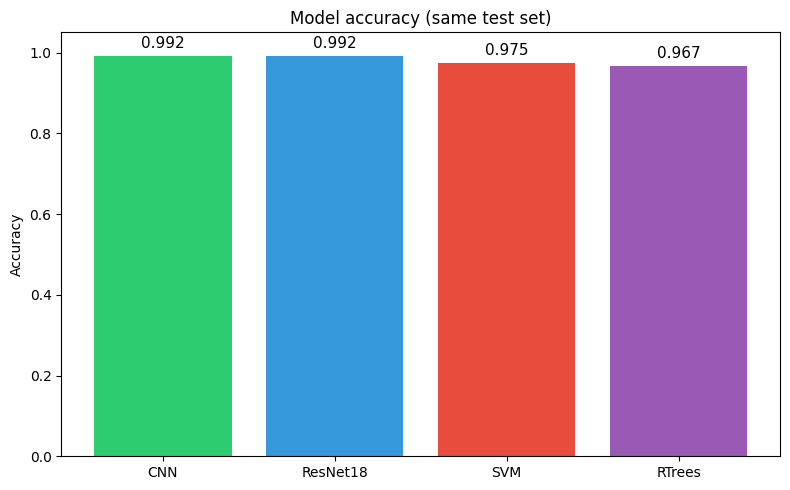

In [26]:
accuracies = {name: accuracy_score(y_true, r["y_pred"]) for name, r in results.items()}
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]
bars = ax.bar(accuracies.keys(), accuracies.values(), color=colors)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Model accuracy (same test set)")
for bar, v in zip(bars, accuracies.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{v:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Confusion matrices (all 4 models)

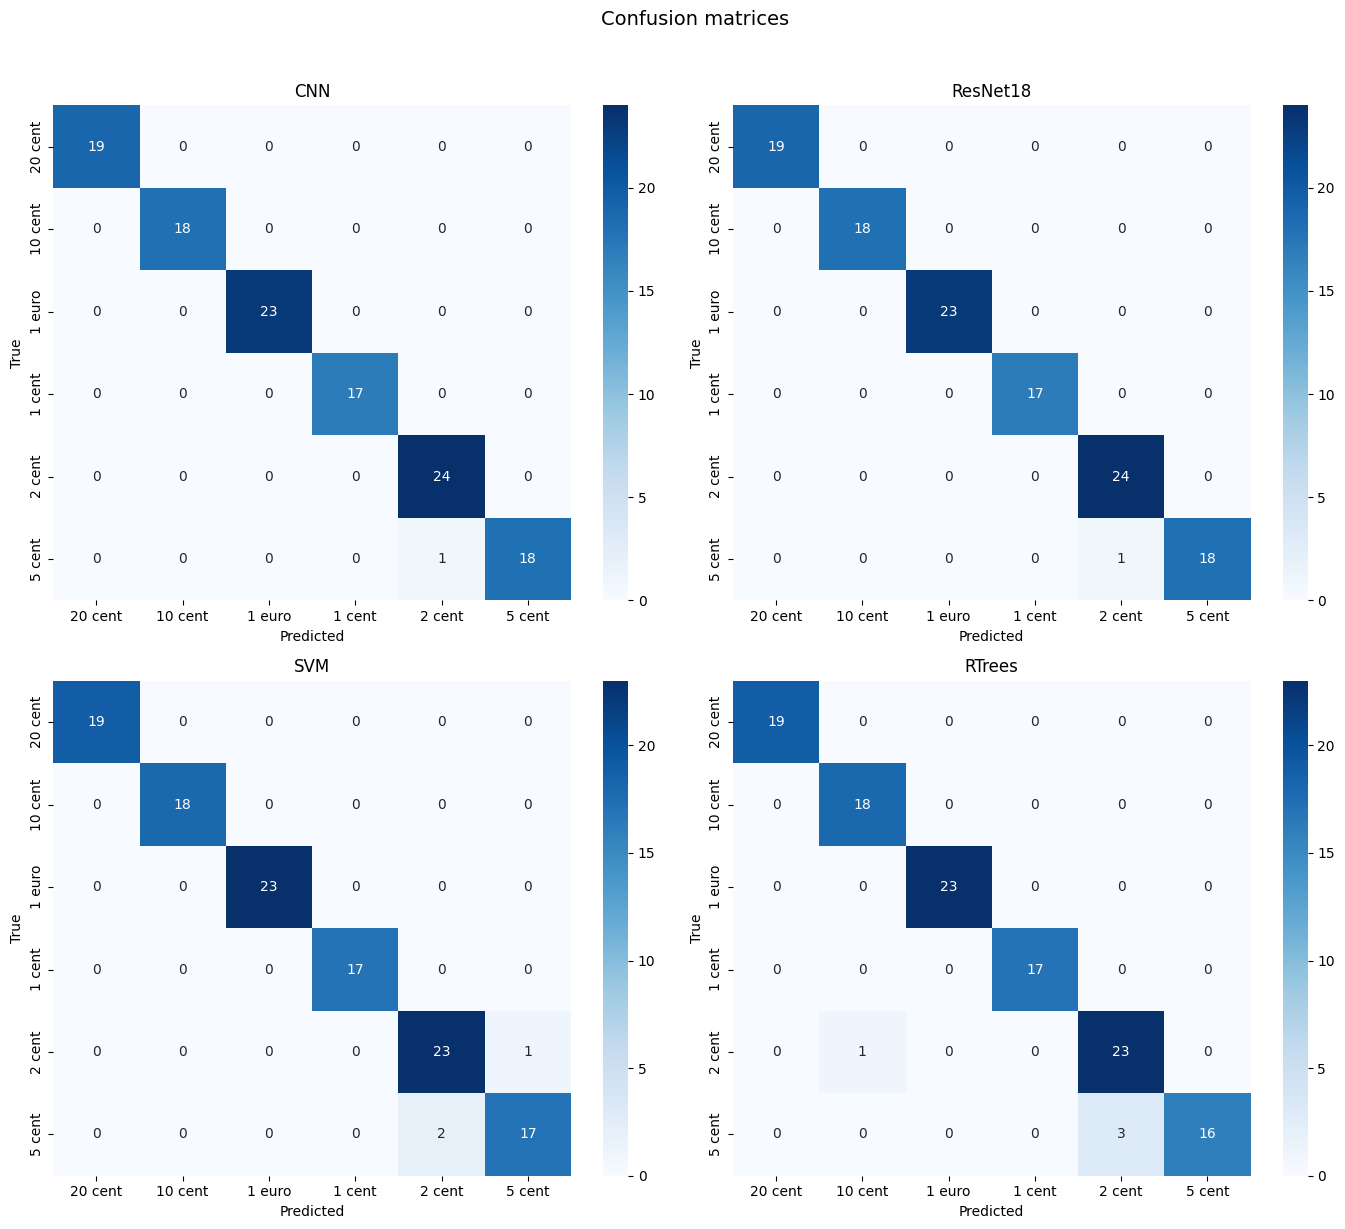

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_true, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Confusion matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Per-class precision, recall, F1 (grouped bar charts)

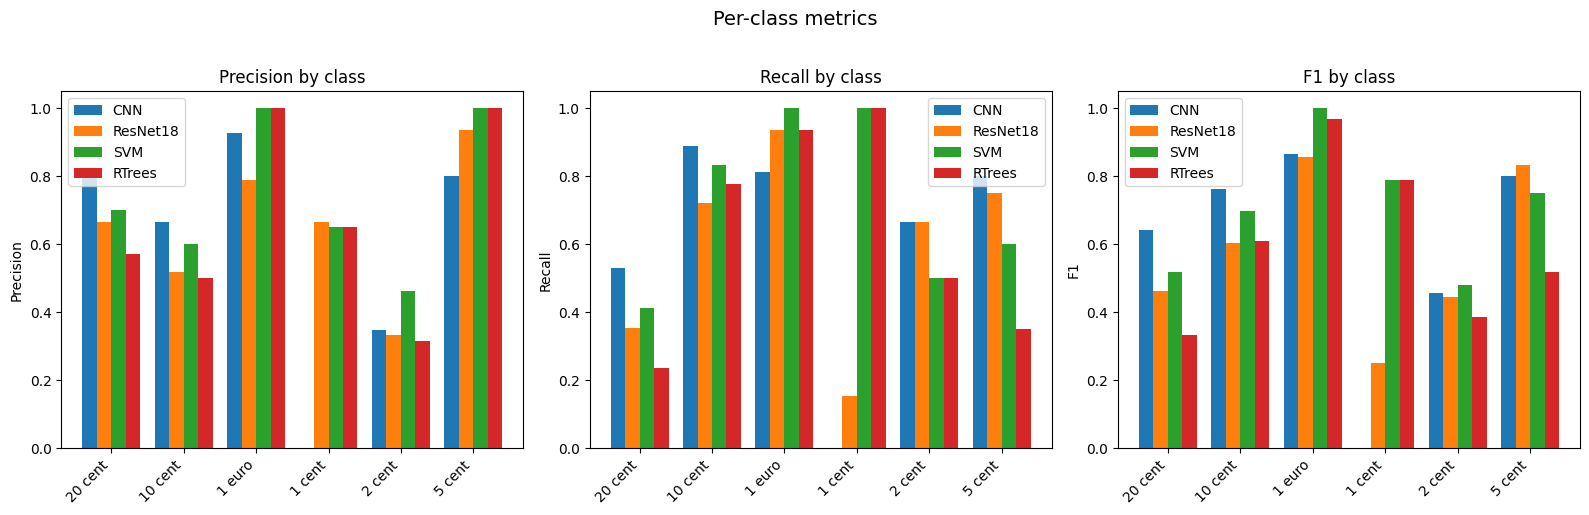

In [8]:
from sklearn.metrics import precision_recall_fscore_support

metrics_by_model = {}
for name, r in results.items():
    p, r, f, _ = precision_recall_fscore_support(y_true, r["y_pred"], average=None, zero_division=0)
    metrics_by_model[name] = {"precision": p, "recall": r, "f1": f}

x = np.arange(len(CLASS_NAMES))
width = 0.2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metric in enumerate(["precision", "recall", "f1"]):
    ax = axes[i]
    for j, (name, m) in enumerate(metrics_by_model.items()):
        ax.bar(x + j*width, m[metric], width, label=name)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_ylabel(metric.capitalize())
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_title(metric.capitalize() + " by class")
plt.suptitle("Per-class metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Inference time comparison

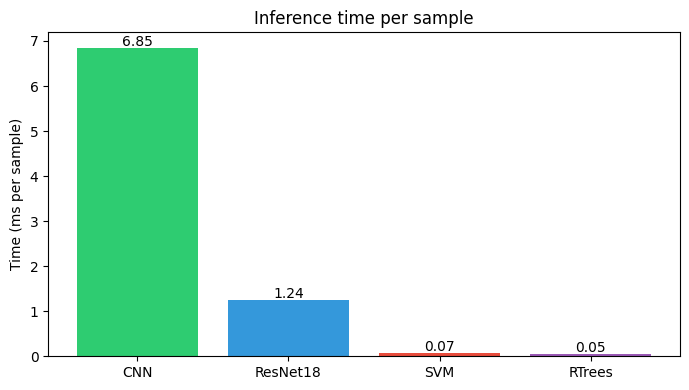

In [9]:
times_ms = [results[n]["time_ms"] for n in results]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results.keys(), times_ms, color=["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"])
ax.set_ylabel("Time (ms per sample)")
ax.set_title("Inference time per sample")
for b, t in zip(bars, times_ms):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05, f"{t:.2f}", ha="center")
plt.tight_layout()
plt.show()

## 9b. Accuracy vs inference time (trade-off)

All four models: higher accuracy vs faster inference.

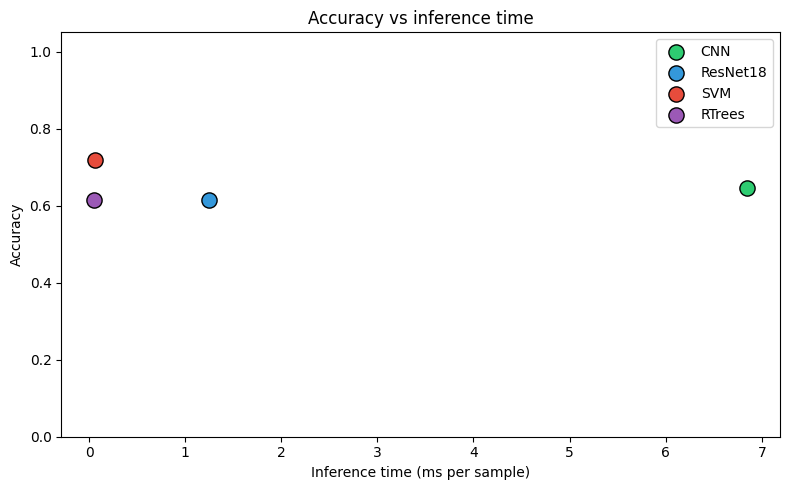

In [10]:
accs = [accuracy_score(y_true, results[n]["y_pred"]) for n in results]
times = [results[n]["time_ms"] for n in results]
names = list(results.keys())
colors = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]
fig, ax = plt.subplots(figsize=(8, 5))
for i, (a, t) in enumerate(zip(accs, times)):
    ax.scatter(t, a, s=120, c=colors[i], label=names[i], edgecolors="black")
ax.set_xlabel("Inference time (ms per sample)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs inference time")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 10. DL-specific: CNN vs ResNet — model size (parameters)

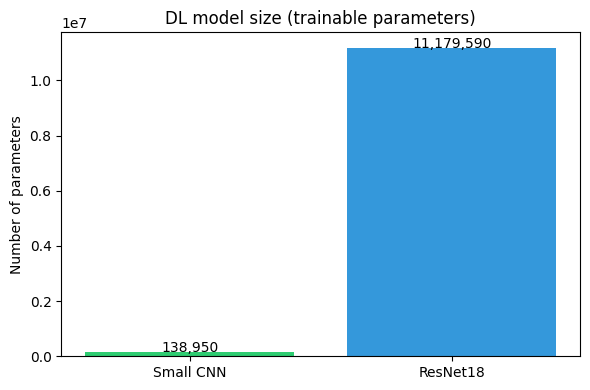

CNN: 138,950 params | ResNet18: 11,179,590 params


In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

params_cnn = count_parameters(model_cnn)
params_resnet = count_parameters(model_resnet)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Small CNN", "ResNet18"], [params_cnn, params_resnet], color=["#2ecc71", "#3498db"])
ax.set_ylabel("Number of parameters")
ax.set_title("DL model size (trainable parameters)")
for i, v in enumerate([params_cnn, params_resnet]):
    ax.text(i, v + 0.5e4, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()
print(f"CNN: {params_cnn:,} params | ResNet18: {params_resnet:,} params")

## 10b. DL-specific: FLOPs (floating-point operations per forward pass)

Requires `pip install thop`. Compares compute cost of CNN vs ResNet18 per inference.

In [12]:
try:
    from thop import profile
    example = torch.randn(1, 3, CROP_SIZE, CROP_SIZE).to(device)
    flops_cnn, _ = profile(model_cnn, inputs=(example,))
    flops_resnet, _ = profile(model_resnet, inputs=(example,))
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["Small CNN", "ResNet18"], [flops_cnn/1e6, flops_resnet/1e6], color=["#2ecc71", "#3498db"])
    ax.set_ylabel("FLOPs (millions)")
    ax.set_title("DL: FLOPs per forward pass (150×150 input)")
    for i, v in enumerate([flops_cnn/1e6, flops_resnet/1e6]):
        ax.text(i, v + 5, f"{v:.1f}M", ha="center")
    plt.tight_layout()
    plt.show()
    print(f"CNN: {flops_cnn/1e6:.2f} MFLOPs | ResNet18: {flops_resnet/1e6:.2f} MFLOPs")
except ImportError:
    print("Install thop for FLOPs: pip install thop")

Install thop for FLOPs: pip install thop


## 11. DL-specific: Confidence distribution (max softmax)

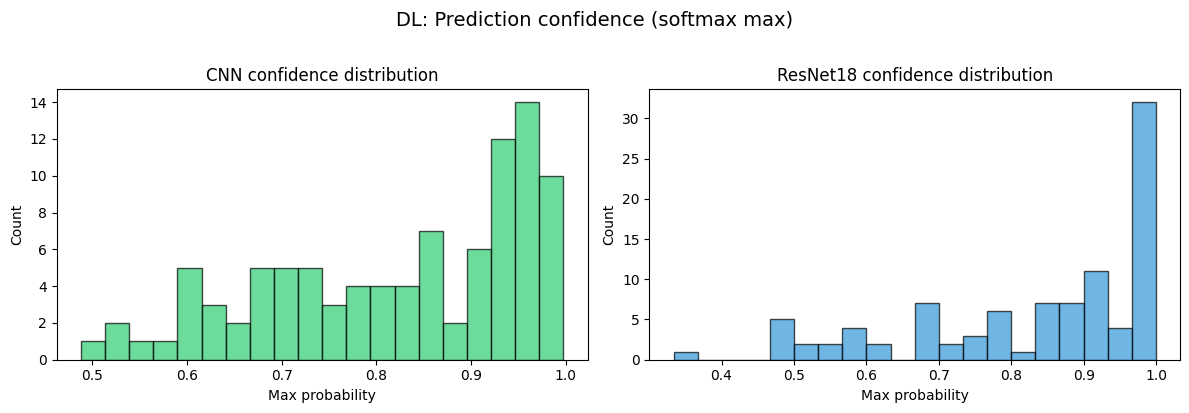

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(results["CNN"]["conf"], bins=20, color="#2ecc71", alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Max probability")
axes[0].set_ylabel("Count")
axes[0].set_title("CNN confidence distribution")
axes[1].hist(results["ResNet18"]["conf"], bins=20, color="#3498db", alpha=0.7, edgecolor="black")
axes[1].set_xlabel("Max probability")
axes[1].set_ylabel("Count")
axes[1].set_title("ResNet18 confidence distribution")
plt.suptitle("DL: Prediction confidence (softmax max)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. DL-specific: Confidence vs correct (calibration-style)

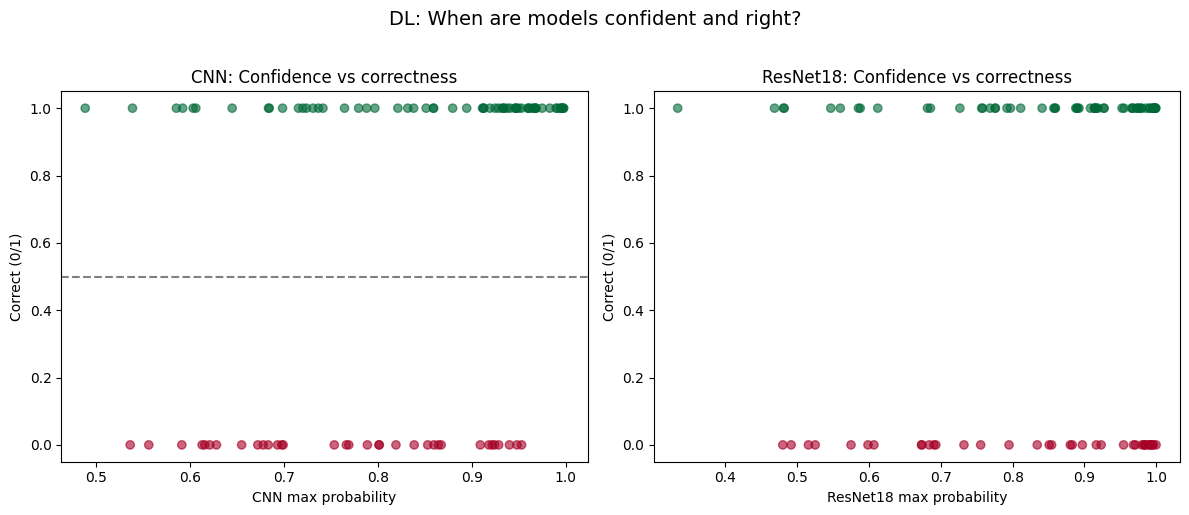

In [14]:
correct_cnn = (y_cnn == y_true).astype(int)
correct_resnet = (y_resnet == y_true).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(results["CNN"]["conf"], correct_cnn, alpha=0.6, c=correct_cnn, cmap="RdYlGn")
axes[0].set_xlabel("CNN max probability")
axes[0].set_ylabel("Correct (0/1)")
axes[0].set_title("CNN: Confidence vs correctness")
axes[0].axhline(0.5, color="gray", ls="--")
axes[1].scatter(results["ResNet18"]["conf"], correct_resnet, alpha=0.6, c=correct_resnet, cmap="RdYlGn")
axes[1].set_xlabel("ResNet18 max probability")
axes[1].set_ylabel("Correct (0/1)")
axes[1].set_title("ResNet18: Confidence vs correctness")
plt.suptitle("DL: When are models confident and right?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 13. DL-specific: CNN vs ResNet accuracy by class (side-by-side)

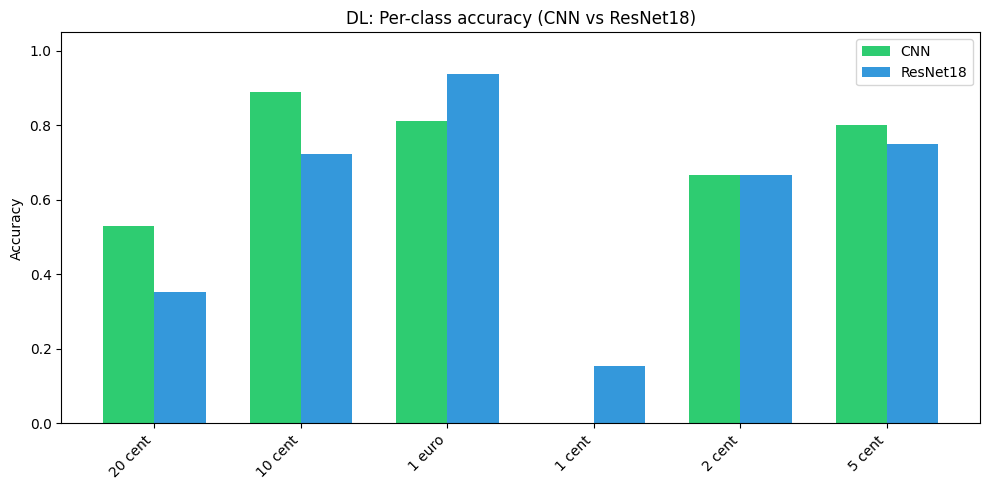

In [15]:
acc_by_class_cnn = []
acc_by_class_resnet = []
for c in range(NUM_CLASSES):
    mask = y_true == c
    if mask.sum() == 0:
        acc_by_class_cnn.append(0.0)
        acc_by_class_resnet.append(0.0)
    else:
        acc_by_class_cnn.append((y_cnn[mask] == c).mean())
        acc_by_class_resnet.append((y_resnet[mask] == c).mean())

x = np.arange(len(CLASS_NAMES))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, acc_by_class_cnn, width, label="CNN", color="#2ecc71")
ax.bar(x + width/2, acc_by_class_resnet, width, label="ResNet18", color="#3498db")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("DL: Per-class accuracy (CNN vs ResNet18)")
plt.tight_layout()
plt.show()

## 14. DL-specific: ROC curves (one-vs-rest, CNN and ResNet)

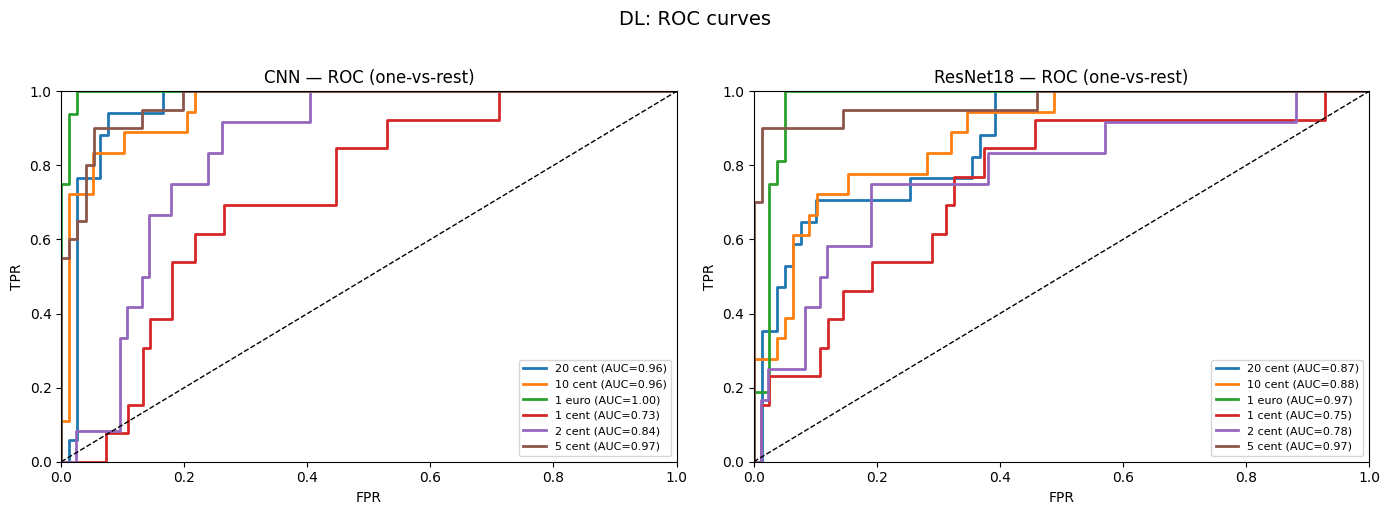

In [16]:
y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name, probs in zip(axes, ["CNN", "ResNet18"], [results["CNN"]["probs"], results["ResNet18"]["probs"]]):
    for c in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, c], probs[:, c])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{CLASS_NAMES[c]} (AUC={roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(f"{name} — ROC (one-vs-rest)")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.suptitle("DL: ROC curves", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 15. Agreement between models (prediction correlation heatmap)

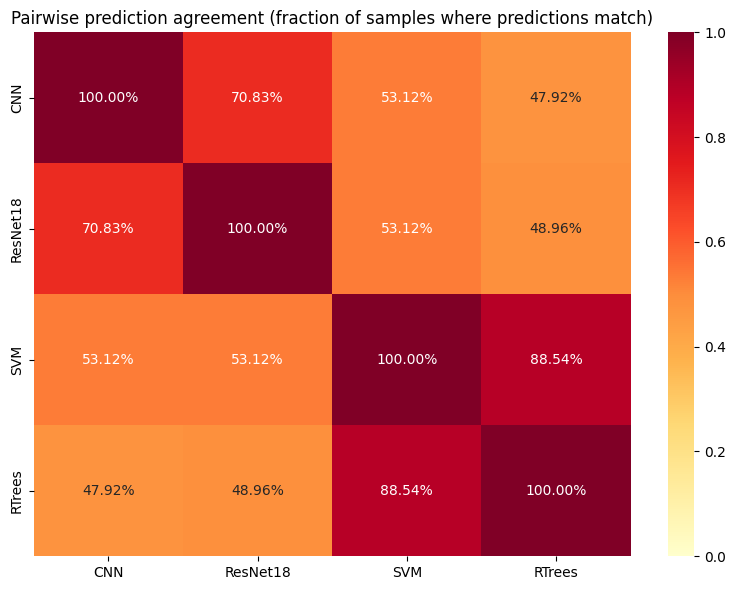

In [17]:
model_names = list(results.keys())
n_models = len(model_names)
agree = np.zeros((n_models, n_models))
for i in range(n_models):
    for j in range(n_models):
        agree[i, j] = (results[model_names[i]]["y_pred"] == results[model_names[j]]["y_pred"]).mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(agree, xticklabels=model_names, yticklabels=model_names, annot=True, fmt=".2%", cmap="YlOrRd", ax=ax, vmin=0, vmax=1)
ax.set_title("Pairwise prediction agreement (fraction of samples where predictions match)")
plt.tight_layout()
plt.show()

## 16. Summary table (accuracy, time, params)

In [18]:
rows_summary = []
for name in results:
    r = results[name]
    row = {"Model": name, "Accuracy": accuracy_score(y_true, r["y_pred"]), "Time (ms/sample)": r["time_ms"]}
    if name == "CNN":
        row["Parameters"] = params_cnn
    elif name == "ResNet18":
        row["Parameters"] = params_resnet
    else:
        row["Parameters"] = "—"
    rows_summary.append(row)

df = pd.DataFrame(rows_summary)
display(df)

,Model,Accuracy,Time (ms/sample),Parameters
0,CNN,0.645833,6.849475,138950
1,ResNet18,0.614583,1.243054,11179590
2,SVM,0.718750,0.065515,—
3,RTrees,0.614583,0.050783,—


## 17. Sample misclassifications (first 8 errors per model)

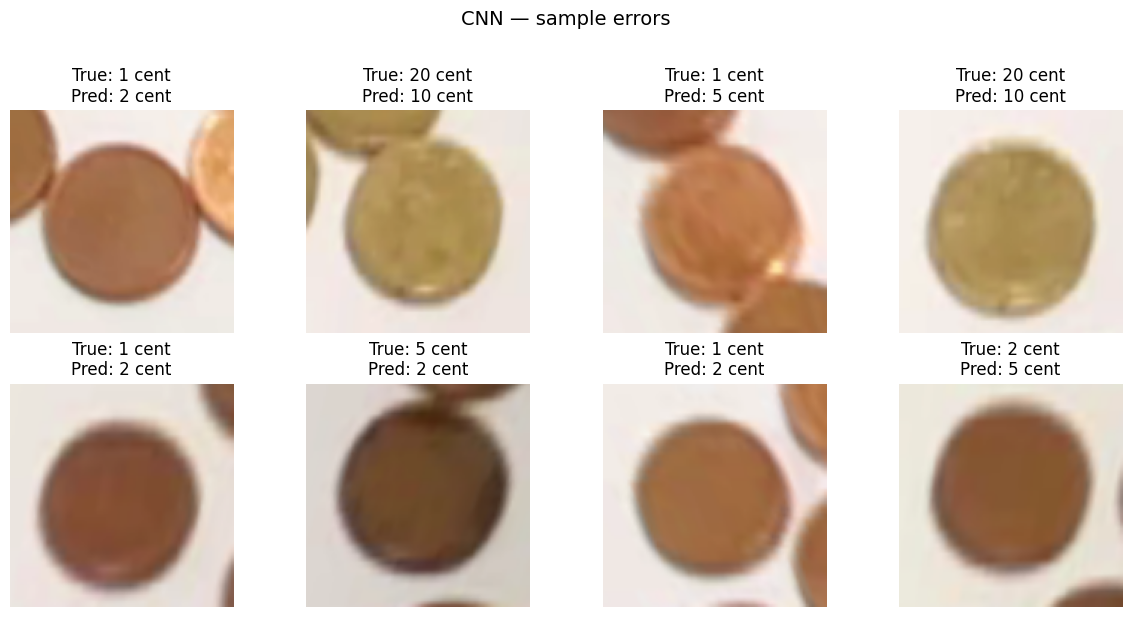

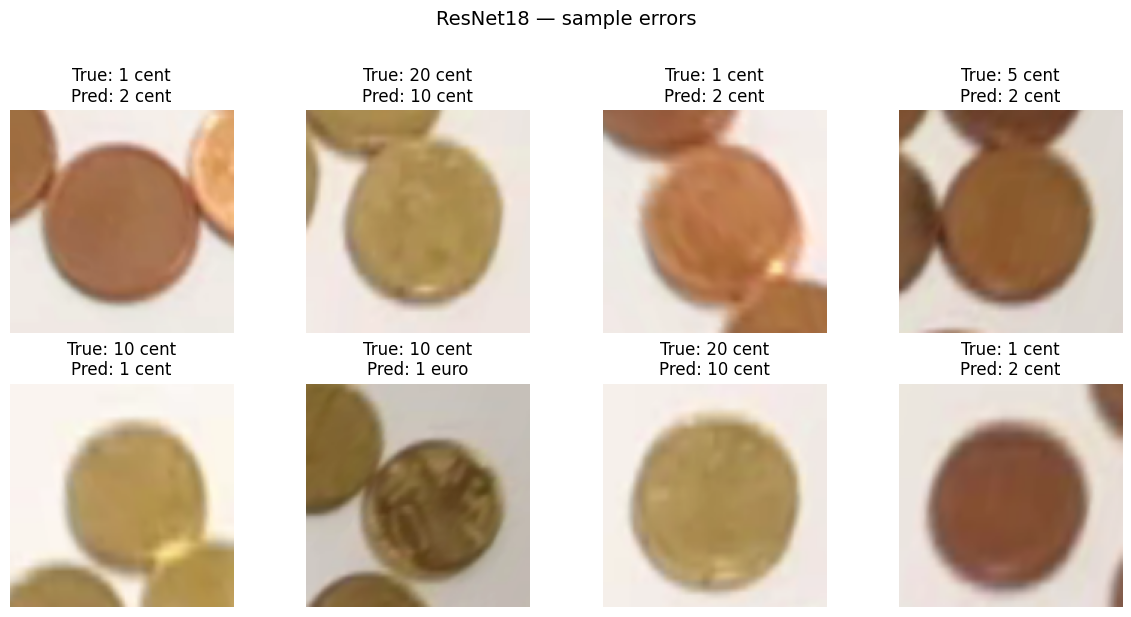

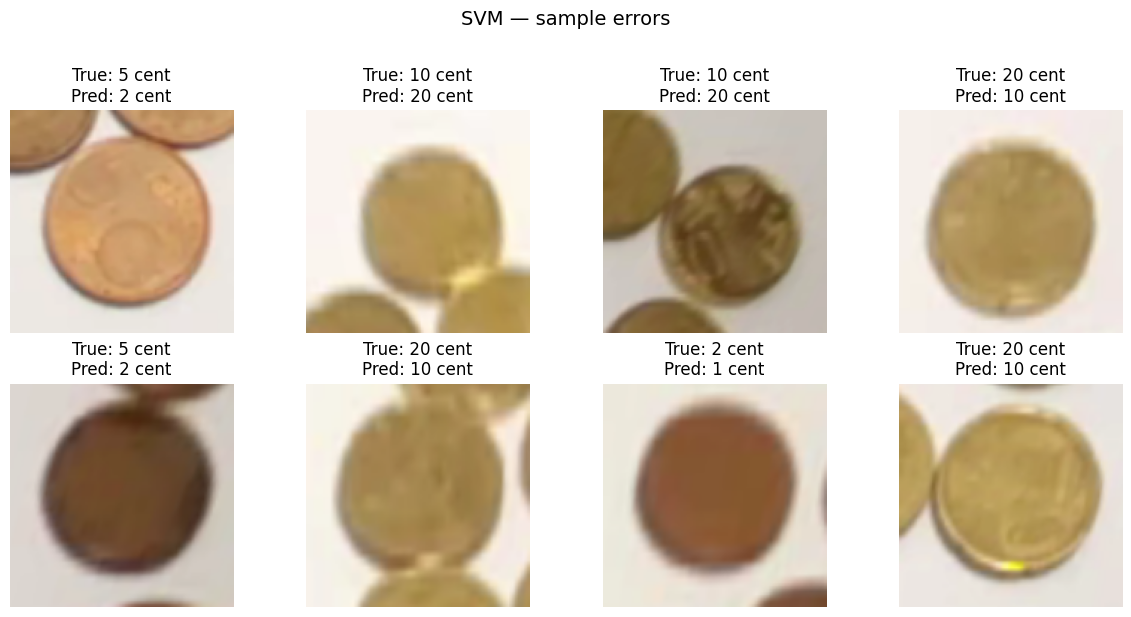

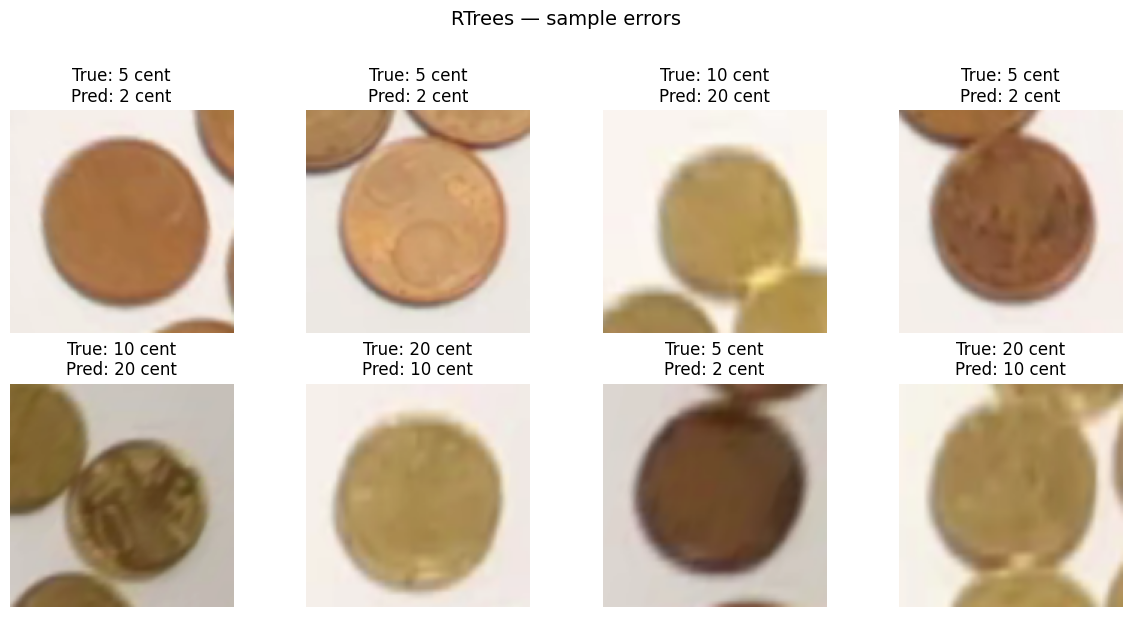

In [19]:
def plot_errors(model_name, y_pred, n_show=8):
    err_idx = np.where(y_pred != y_true)[0]
    if len(err_idx) == 0:
        print(f"{model_name}: no errors.")
        return
    show_idx = err_idx[:n_show]
    n_plot = len(show_idx)
    cols = 4
    rows = (n_plot + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    for k, idx in enumerate(show_idx):
        ax = axes.flat[k]
        ax.imshow(X_crops[idx])
        ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}")
        ax.axis("off")
    for k in range(n_plot, rows*cols):
        axes.flat[k].axis("off")
    plt.suptitle(f"{model_name} — sample errors", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

for name, r in results.items():
    plot_errors(name, r["y_pred"])

## 18. DL-specific: Class-wise mean confidence (correct vs incorrect)

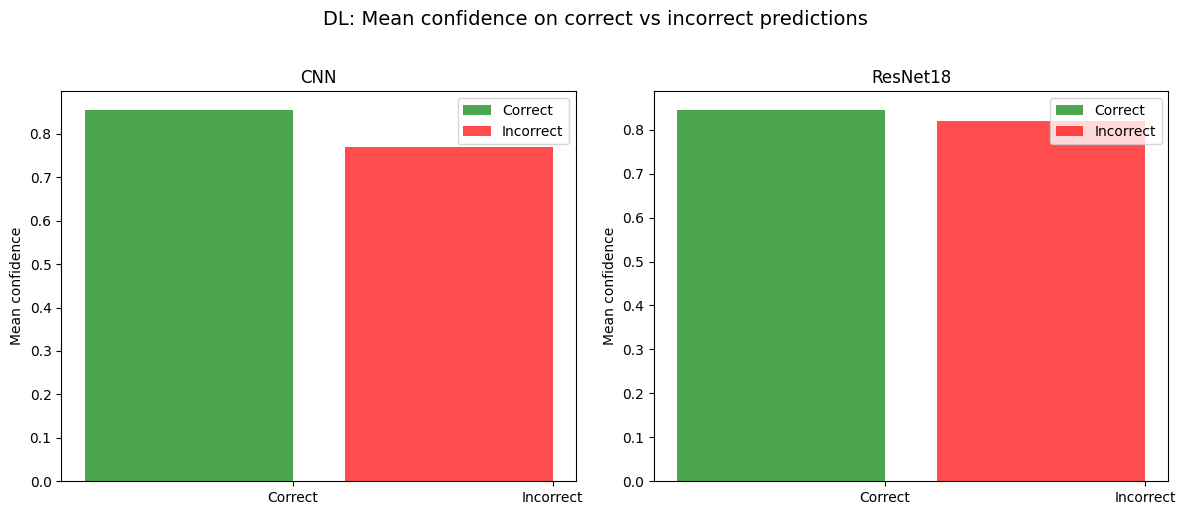

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, conf in zip(axes, ["CNN", "ResNet18"], [results["CNN"]["conf"], results["ResNet18"]["conf"]]):
    correct = (results[name]["y_pred"] == y_true)
    ax.bar([0], [conf[correct].mean()], width=0.4, label="Correct", color="green", alpha=0.7)
    ax.bar([0.5], [conf[~correct].mean()], width=0.4, label="Incorrect", color="red", alpha=0.7)
    ax.set_xticks([0.2, 0.7])
    ax.set_xticklabels(["Correct", "Incorrect"])
    ax.set_ylabel("Mean confidence")
    ax.set_title(f"{name}")
    ax.legend()
plt.suptitle("DL: Mean confidence on correct vs incorrect predictions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()